<a href="https://colab.research.google.com/github/GasserElbanna/voice-speech-metamers/blob/deepfake/Deepfake_Analysis_SpeakerDistance_vs_Rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install speechbrain

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [ ]:
from collections import defaultdict

import torch
import torchaudio
import IPython
import os
import glob
import pandas as pd
import numpy as np
from transformers import Wav2Vec2Model
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from speechbrain.inference.encoders import WaveformEncoder
import matplotlib.pyplot as plt

In [ ]:
%%capture
!pip install datasets -U
!pip install librosa
!pip install jiwer

https://huggingface.co/openai/whisper-medium

In [ ]:
# !pip install --upgrade pyarrow

In [ ]:
# prompt: mount my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Models

In [ ]:
# load model and processor
processor = WhisperProcessor.from_pretrained("openai/whisper-base", language='en')
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base")
model.config.forced_decoder_ids = None


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/3.81k [00:00<?, ?B/s]

# Whisper Analysis

In [ ]:
## list all the audios in the fake and real dataset
real_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/*.wav')
fake_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE_PARSED/*.wav')

# ECAPA-TDNN Analysis
#### https://huggingface.co/speechbrain/spkrec-ecapa-voxceleb

In [ ]:
from speechbrain.inference.speaker import SpeakerRecognition
from speechbrain.inference.speaker import EncoderClassifier

In [ ]:
verification = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/spkrec-ecapa-voxceleb")


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

# Comparison with Human Rating

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/Copy of Voice_Identification_Experiment - Annesya.csv')

In [ ]:
audio_path = df['Unnamed: 1'][22:]

In [ ]:
audio_path.iloc[0]

'trump-to-taylor_40.wav'

In [ ]:
audio_3_path

'/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/Obama-original_2.wav'

In [ ]:
speaker_verification_fake = pd.DataFrame()

fake_speakers_rating = []
fake_speakers_score_rating_12 = []
fake_speakers_score_rating_13 = []


target_length = 20 # number of seconds
sr = 16000
num_samples = int(target_length * sr)

resampler = torchaudio.transforms.Resample(44100, 16000)

for i in range(len(audio_path)):
  audio_1_path = os.path.join('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE_PARSED/',audio_path.iloc[i])
  audio_2_path = os.path.join(
      '/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/',
      audio_path.iloc[i].split('-')[0]+'-original_'+audio_path.iloc[i].split('_')[1]) ## source speaker
  audio_3_path = os.path.join(
      '/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/',
      audio_path.iloc[i].split('-')[2].split('_')[0].lower()+'-original_2.wav') ## target speaker

  fake_audio, sr_audio = torchaudio.load(audio_1_path)
  fake_audio = resampler(fake_audio)
  input_audio_1 = fake_audio[0,:]
  fake_audio, sr_audio = torchaudio.load(audio_2_path)
  fake_audio = resampler(fake_audio)
  input_audio_2 = fake_audio[0,:]
  fake_audio, sr_audio = torchaudio.load(audio_3_path)
  fake_audio = resampler(fake_audio)
  input_audio_3 = fake_audio[0,:]
  score12, prediction = verification.verify_batch(input_audio_1,input_audio_2)
  score13, prediction = verification.verify_batch(input_audio_1,input_audio_3)
  fake_speakers_rating.append(prediction)
  fake_speakers_score_rating_12.append(score12) # score between fake voice and source real voice -- high score means the fake voice retains a lot of info from the source voice, i.e., not good deepfake
  fake_speakers_score_rating_13.append(score13) # score between target voice real and fake -- high score means the deepfaking is good; should match with human rating


In [ ]:
sub_1 = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/Voice_Identification_Experiment - Gasser.csv')
sub_2 = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/Voice_Identification_Experiment - Sagarika.csv')
sub_3 = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/Voice_Identification_Experiment - Richard.csv')
sub_4 = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/Voice_Identification_Experiment - Annika.csv')
sub_5 = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/Voice_Identification_Experiment - Ajani.csv')
sub_6 = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/Voice_Identification_Experiment - AI agent.csv')

In [ ]:
sub_1_rating = sub_1['Unnamed: 4'][24:]
sub_2_rating = sub_2['Unnamed: 4'][24:]
sub_3_rating = sub_3['Unnamed: 4'][22:]
sub_4_rating = sub_4['Unnamed: 4'][24:]
sub_5_rating = sub_5['Unnamed: 4'][24:]
sub_6_rating = sub_6['Unnamed: 4'][24:]

In [ ]:
sub_1_rating = [sub_1_rating.iloc[i] for i in range(len(sub_1_rating))]
sub_2_rating = [sub_2_rating.iloc[i] for i in range(len(sub_2_rating))]
sub_3_rating = [sub_3_rating.iloc[i] for i in range(len(sub_3_rating))]
sub_4_rating = [sub_4_rating.iloc[i] for i in range(len(sub_4_rating))]
sub_5_rating = [sub_5_rating.iloc[i] for i in range(len(sub_5_rating))]
sub_6_rating = [sub_6_rating.iloc[i] for i in range(len(sub_6_rating))]

In [ ]:
len(sub_4_rating)

32

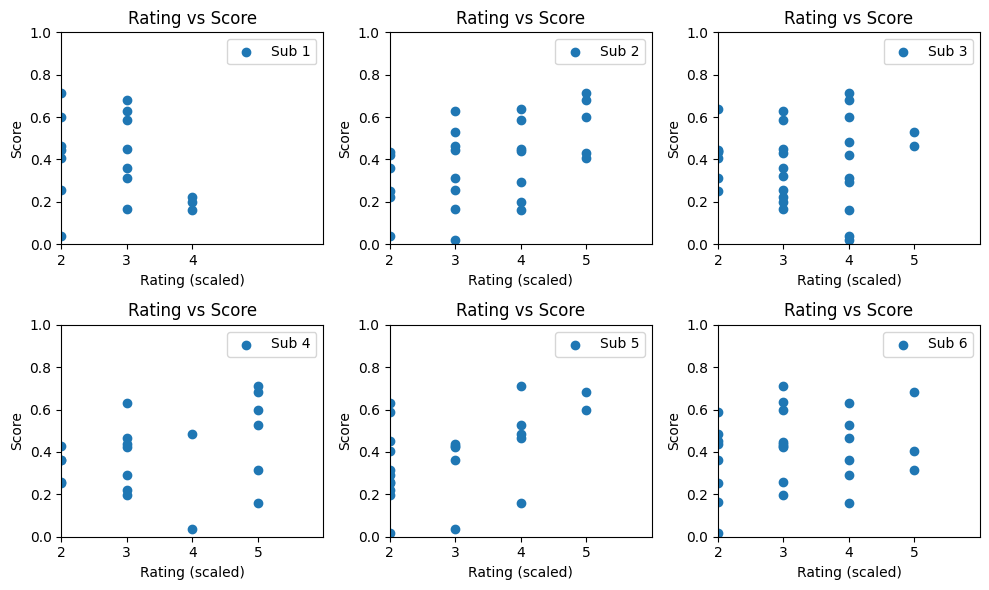

In [ ]:
import matplotlib.pyplot as plt

# Sort the data for Sub 1
sorted_data_1 = sorted(zip(sub_1_rating, fake_speakers_score_rating_13))
sub_1_rating_sorted, fake_speakers_score_rating_sorted_1 = zip(*sorted_data_1)

# Sort the data for Sub 2
sorted_data_2 = sorted(zip(sub_2_rating, fake_speakers_score_rating_13))
sub_2_rating_sorted, fake_speakers_score_rating_sorted_2 = zip(*sorted_data_2)

# Sort the data for Sub 3
sorted_data_3 = sorted(zip(sub_3_rating, fake_speakers_score_rating_13))
sub_3_rating_sorted, fake_speakers_score_rating_sorted_3 = zip(*sorted_data_3)

# Sort the data for Sub 4
sorted_data_4 = sorted(zip(sub_4_rating, fake_speakers_score_rating_13))
sub_4_rating_sorted, fake_speakers_score_rating_sorted_4 = zip(*sorted_data_4)

# Sort the data for Sub 5
sorted_data_5 = sorted(zip(sub_5_rating, fake_speakers_score_rating_13))
sub_5_rating_sorted, fake_speakers_score_rating_sorted_5 = zip(*sorted_data_5)

# Sort the data for Sub 6
sorted_data_6 = sorted(zip(sub_6_rating, fake_speakers_score_rating_13))
sub_6_rating_sorted, fake_speakers_score_rating_sorted_6 = zip(*sorted_data_6)

plt.figure(figsize=[10,6])

plt.subplot(2,3,1)
plt.scatter(sub_1_rating_sorted, fake_speakers_score_rating_sorted_1, label='Sub 1')
plt.legend()
plt.ylim([0,1])
plt.xlabel('Rating (scaled)')
plt.ylabel('Score')
plt.title('Rating vs Score')
plt.xlim([1,5])
plt.ylim([0,1])

plt.subplot(2,3,2)
plt.scatter(sub_2_rating_sorted, fake_speakers_score_rating_sorted_2, label='Sub 2')
plt.legend()
plt.ylim([0,1])
plt.xlabel('Rating (scaled)')
plt.ylabel('Score')
plt.title('Rating vs Score')
plt.xlim([1,5])
plt.ylim([0,1])

plt.subplot(2,3,3)
plt.scatter(sub_3_rating_sorted, fake_speakers_score_rating_sorted_3, label='Sub 3')
plt.legend()
plt.ylim([0,1])
plt.xlabel('Rating (scaled)')
plt.ylabel('Score')
plt.title('Rating vs Score')
plt.xlim([1,5])
plt.ylim([0,1])

plt.subplot(2,3,4)
plt.scatter(sub_4_rating_sorted, fake_speakers_score_rating_sorted_4, label='Sub 4')
plt.legend()
plt.ylim([0,1])
plt.xlabel('Rating (scaled)')
plt.ylabel('Score')
plt.title('Rating vs Score')
plt.xlim([1,5])
plt.ylim([0,1])

plt.subplot(2,3,5)
plt.scatter(sub_5_rating_sorted, fake_speakers_score_rating_sorted_5, label='Sub 5')
plt.legend()
plt.ylim([0,1])
plt.xlabel('Rating (scaled)')
plt.ylabel('Score')
plt.title('Rating vs Score')
plt.xlim([1,5])
plt.ylim([0,1])

plt.subplot(2,3,6)
plt.scatter(sub_6_rating_sorted, fake_speakers_score_rating_sorted_6, label='Sub 6')
plt.legend()
plt.ylim([0,1])
plt.xlabel('Rating (scaled)')
plt.ylabel('Score')
plt.title('Rating vs Score')
plt.xlim([1,5])
plt.ylim([0,1])

plt.tight_layout()
plt.show()


In [ ]:
fake_speakers_score_rating_flat = [fake_speakers_score_rating_13[i][0][0] for i in range(len(fake_speakers_score_rating_13))]

In [ ]:
sub_1_rating = [int(sub_1_rating[i]) for i in range(len(sub_1_rating))]
sub_2_rating = [int(sub_2_rating[i]) for i in range(len(sub_2_rating))]
sub_3_rating = [int(sub_3_rating[i]) for i in range(len(sub_3_rating))]
sub_4_rating = [int(sub_4_rating[i]) for i in range(len(sub_4_rating))]
sub_5_rating = [int(sub_5_rating[i]) for i in range(len(sub_5_rating))]
sub_6_rating = [int(sub_6_rating[i]) for i in range(len(sub_6_rating))]

In [ ]:
sub_1_rating_scaled = 0.25*(np.array(sub_1_rating)-1)
sub_2_rating_scaled = 0.25*(np.array(sub_2_rating)-1)
sub_3_rating_scaled = 0.25*(np.array(sub_3_rating)-1)

In [ ]:
print(np.corrcoef(sub_1_rating, np.array(fake_speakers_score_rating_flat))[0][1])
print(np.corrcoef(sub_2_rating, np.array(fake_speakers_score_rating_flat))[0][1])
print(np.corrcoef(sub_3_rating, np.array(fake_speakers_score_rating_flat))[0][1])
print(np.corrcoef(sub_4_rating, np.array(fake_speakers_score_rating_flat))[0][1])
print(np.corrcoef(sub_5_rating, np.array(fake_speakers_score_rating_flat))[0][1])
print(np.corrcoef(sub_6_rating, np.array(fake_speakers_score_rating_flat))[0][1])


-0.15451502675892206
0.35347173295657125
0.04954727059697191
0.25824453231276323
0.3855835574159095
0.37920933116028055


In [ ]:
subject_response_mean = (np.array(sub_1_rating)+np.array(sub_2_rating)+np.array(sub_3_rating)+np.array(sub_4_rating)+np.array(sub_5_rating)+np.array(sub_6_rating))/6

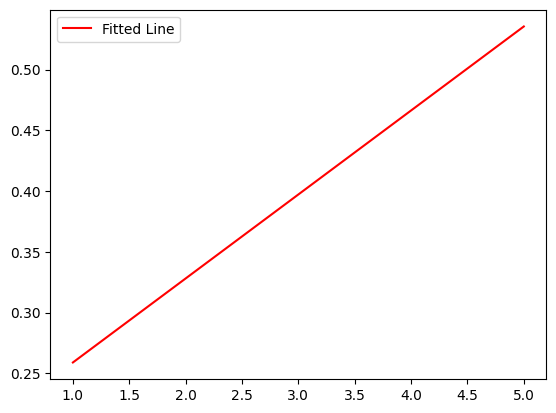

In [ ]:
# prompt: fit a linear curve to the above scatter plot

# Fit a linear curve (polynomial of degree 1)
coefficients = np.polyfit(subject_response_mean, fake_speakers_score_rating_flat, 1)
poly_function = np.poly1d(coefficients)

# Generate x values for the fitted line
x_values = np.linspace(1, 5, 100)
y_values = poly_function(x_values)

# Plot the fitted line
plt.plot(x_values, y_values, color='red', label='Fitted Line')
plt.legend()


In [ ]:
poly_function

poly1d([0.06910723, 0.1898787 ])

(0.0, 1.0)

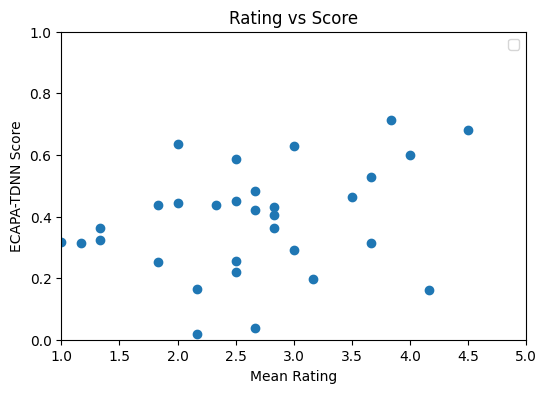

In [ ]:
plt.figure(figsize=[6,4])
plt.scatter(subject_response_mean, fake_speakers_score_rating_flat)
# plt.plot(x_values, y_values, color='red', label='Fitted Line')
plt.legend()
plt.ylim([0,1])
plt.xlabel('Mean Rating')
plt.ylabel('ECAPA-TDNN Score')
plt.title('Rating vs Score')
plt.xlim([1,5])
plt.ylim([0,1])

In [ ]:
print(np.corrcoef(subject_response_mean, np.array(fake_speakers_score_rating_flat))[0][1])

0.31976432509412295


#### Comparing transcripts with scores

In [ ]:
real_transcript = []
fake_transcript = []

for i in range(len(audio_path)):
  audio_1_path = os.path.join('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE_PARSED/',audio_path.iloc[i])
  audio_2_path = os.path.join(
      '/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/',
      audio_path.iloc[i].split('-')[0]+'-original_'+audio_path.iloc[i].split('_')[1])

  fake_audio, sr_audio = torchaudio.load(audio_1_path)
  fake_audio = resampler(fake_audio)
  input_audio_1 = fake_audio[0,:]
  fake_audio, sr_audio = torchaudio.load(audio_2_path)
  fake_audio = resampler(fake_audio)
  input_audio_2 = fake_audio[0,:]

  input_features_1 = processor(input_audio_1, sampling_rate=sr, return_tensors="pt").input_features
  input_features_2 = processor(input_audio_2, sampling_rate=sr, return_tensors="pt").input_features

  predicted_ids_1 = model.generate(input_features_1)
  predicted_ids_2 = model.generate(input_features_2)
  # decode token ids to text
  transcription_1 = processor.batch_decode(predicted_ids_1, skip_special_tokens=True)
  transcription_2 = processor.batch_decode(predicted_ids_2, skip_special_tokens=True)
  fake_transcript.append(transcription_1)
  real_transcript.append(transcription_2)

Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
from jiwer import wer

result = []

for i in range(len(fake_transcript)):
  try:
    val = wer(str(fake_transcript[i]), str(real_transcript[i]))
    result.append(val)
  except:
    pass

In [ ]:
len(result)

32

Text(0.5, 1.0, 'WER vs Rating')

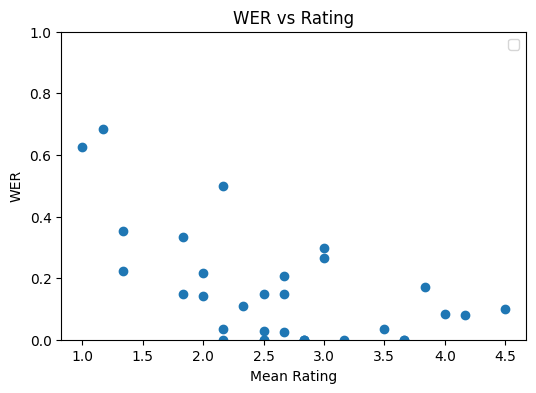

In [ ]:
plt.figure(figsize=[6,4])
plt.scatter(subject_response_mean, result)
plt.legend()
plt.ylim([0,1])
plt.xlabel('Mean Rating')
plt.ylabel('WER')
plt.title('WER vs Rating')

In [ ]:
np.corrcoef(result, subject_response_mean)[0][1]

-0.5701916364856945

Identify voice conversion that are rated good enough (>3.5)

In [ ]:
indices = np.where(np.array(subject_response_mean) > 3.5)[0]
indices

array([12, 19, 20, 24, 29, 31])

In [ ]:
conversions_to_take = []

for i in range(len(indices)):
  audio_parse = audio_path.iloc[indices[i]].split('_')[0]
  conversions_to_take.append(audio_parse)

In [ ]:
# identify all the fake audio in the fake_parsed data that follow the above conversions

audio_list_fake_parsed = []
for i in range(len(fake_files_list)):
  audio = fake_files_list[i].split('/')[-1].split('_')[0]
  if audio in conversions_to_take:
    audio_list_fake_parsed.append(fake_files_list[i])

In [ ]:
real_transcript_selected = []
fake_transcript_selected = []

for i in range(len(audio_list_fake_parsed)):

  audio_1_path = os.path.join('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE_PARSED/',audio_list_fake_parsed[i])
  # Extract the filename from 'audio_list_fake_parsed[i]' and construct 'audio_2_path'
  filename = audio_list_fake_parsed[i].split('/')[-1]
  audio_2_path = os.path.join('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/',filename.split('-')[0]+'-original_'+ filename.split('_')[1])

  fake_audio, sr_audio = torchaudio.load(audio_1_path)
  fake_audio = resampler(fake_audio)
  input_audio_1 = fake_audio[0,:]

  fake_audio, sr_audio = torchaudio.load(audio_2_path)
  fake_audio = resampler(fake_audio)
  input_audio_2 = fake_audio[0,:]

  input_features_1 = processor(input_audio_1, sampling_rate=sr, return_tensors="pt").input_features
  input_features_2 = processor(input_audio_2, sampling_rate=sr, return_tensors="pt").input_features

  predicted_ids_1 = model.generate(input_features_1)
  predicted_ids_2 = model.generate(input_features_2)

  # decode token ids to text
  transcription_1 = processor.batch_decode(predicted_ids_1, skip_special_tokens=True)
  transcription_2 = processor.batch_decode(predicted_ids_2, skip_special_tokens=True)

  fake_transcript_selected.append(transcription_1)
  real_transcript_selected.append(transcription_2)

In [ ]:
from jiwer import wer

result = []

for i in range(len(fake_transcript_selected)):
  try:
    val = wer(str(fake_transcript_selected[i]), str(real_transcript_selected[i]))
    result.append(val)
  except:
    pass

In [ ]:
len(result)

246

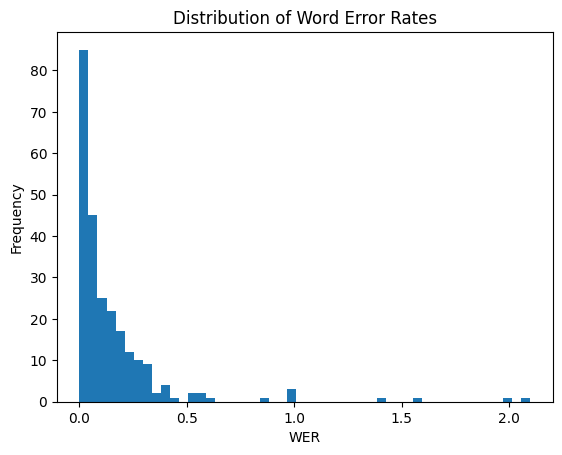

In [ ]:
# prompt: make an histogram from the "result" variable

import matplotlib.pyplot as plt

result_filtered = [result[i] for i in range(len(result)) if result[i] < 5.0]

plt.hist(result_filtered, bins=50)
plt.xlabel('WER')
plt.ylabel('Frequency')
plt.title('Distribution of Word Error Rates')
plt.show()


In [ ]:
min(result)

0.0

In [ ]:
np.mean(result)

0.2270522105817059